<a href="https://colab.research.google.com/github/mushWhoom/airline-customer-segmentation-kmeans/blob/main/Assignment_Day28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/flight.csv')
print("Shape dataset:", df.shape)
print("\nInformasi dataset:")
df.info()

print("\n5 baris pertama:")
df.head()

Shape dataset: (62988, 23)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   6298

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [ ]:

print("\nJumlah missing values per kolom:")
df.isnull().sum()


Jumlah missing values per kolom:


,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2269
WORK_PROVINCE,3248
WORK_COUNTRY,26
AGE,420
LOAD_TIME,0


In [ ]:
# Mengisi Missing Value
df['AGE'].fillna(df['AGE'].median(), inplace=True)
# Lihat distribusi missing pada kolom lain:
missing_cols = ['WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY']
for col in missing_cols:
    df[col].fillna('unknown', inplace=True)
# Kolom GENDER: ada yang kosong? cek
df['GENDER'].fillna('unknown', inplace=True)
# Cek kembali missing
print("\nData Setelah imputasi:")
df.isnull().sum()


Data Setelah imputasi:


,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,0
FFP_TIER,0
WORK_CITY,0
WORK_PROVINCE,0
WORK_COUNTRY,0
AGE,0
LOAD_TIME,0


In [ ]:
# Membuat fitur baru
# Ubah kolom tanggal menjadi datetime
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'])
df['FIRST_FLIGHT_DATE'] = pd.to_datetime(df['FIRST_FLIGHT_DATE'])
df['LOAD_TIME'] = pd.to_datetime(df['LOAD_TIME'])

# Hitung lama keanggotaan dalam hari dari FFP_DATE sampai LOAD_TIME
df['MEMBERSHIP_DAYS'] = (df['LOAD_TIME'] - df['FFP_DATE']).dt.days
# Pilih fitur numerik untuk clustering
features = ['FFP_TIER', 'AGE', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2',
            'SEG_KM_SUM', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL',
            'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight',
            'MEMBERSHIP_DAYS']
# Encoding GENDER (jaga-jaga kalau ingin dimasukkan)
le = LabelEncoder()
df['GENDER_ENCODED'] = le.fit_transform(df['GENDER'].fillna('unknown'))
features.append('GENDER_ENCODED')
# Ambil data yang akan digunakan untuk clustering
X = df[features].copy()



In [ ]:
# Cek missing values di X
print("\nMissing di X:")
print(X.isnull().sum())

for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col].fillna(X[col].median(), inplace=True)
    else:
        pass

# Scaling data sangat penting untuk clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dataset siap digunakan untuk clustering
print("\nData siap! Shape X_scaled:", X_scaled.shape)


Missing di X:
FFP_TIER           0
AGE                0
FLIGHT_COUNT       0
BP_SUM             0
SUM_YR_1           0
SUM_YR_2           0
SEG_KM_SUM         0
LAST_TO_END        0
AVG_INTERVAL       0
MAX_INTERVAL       0
EXCHANGE_COUNT     0
avg_discount       0
Points_Sum         0
Point_NotFlight    0
MEMBERSHIP_DAYS    0
GENDER_ENCODED     0
dtype: int64

Data siap! Shape X_scaled: (62988, 16)


##Exploratory Data Analysis

In [ ]:
# Set style visualisasi nanti
sns.set_style('darkgrid')  # background gelap dengan grid putih
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 10

# Statistik deskriptif untuk semua kolom numerik
print("Statistik Deskriptif Dataset:")
display(df.describe(include=[np.number]).T)

Statistik Deskriptif Dataset:


,count,mean,std,min,25%,50%,75%,max
MEMBER_NO,62988.0,31494.500000,18183.213715,1.0,15747.750000,31494.500000,47241.250000,62988.0
FFP_TIER,62988.0,4.102162,0.373856,4.0,4.000000,4.000000,4.000000,6.0
AGE,62988.0,42.466502,9.853632,6.0,35.000000,41.000000,48.000000,110.0
FLIGHT_COUNT,62988.0,11.839414,14.049471,2.0,3.000000,7.000000,15.000000,213.0
BP_SUM,62988.0,10925.081254,16339.486151,0.0,2518.000000,5700.000000,12831.000000,505308.0
SUM_YR_1,62437.0,5355.376064,8109.450147,0.0,1003.000000,2800.000000,6574.000000,239560.0
SUM_YR_2,62850.0,5604.026014,8703.364247,0.0,780.000000,2773.000000,6845.750000,234188.0
SEG_KM_SUM,62988.0,17123.878691,20960.844623,368.0,4747.000000,9994.000000,21271.250000,580717.0
LAST_TO_END,62988.0,176.120102,183.822223,1.0,29.000000,108.000000,268.000000,731.0
AVG_INTERVAL,62988.0,67.749788,77.517866,0.0,23.370370,44.666667,82.000000,728.0


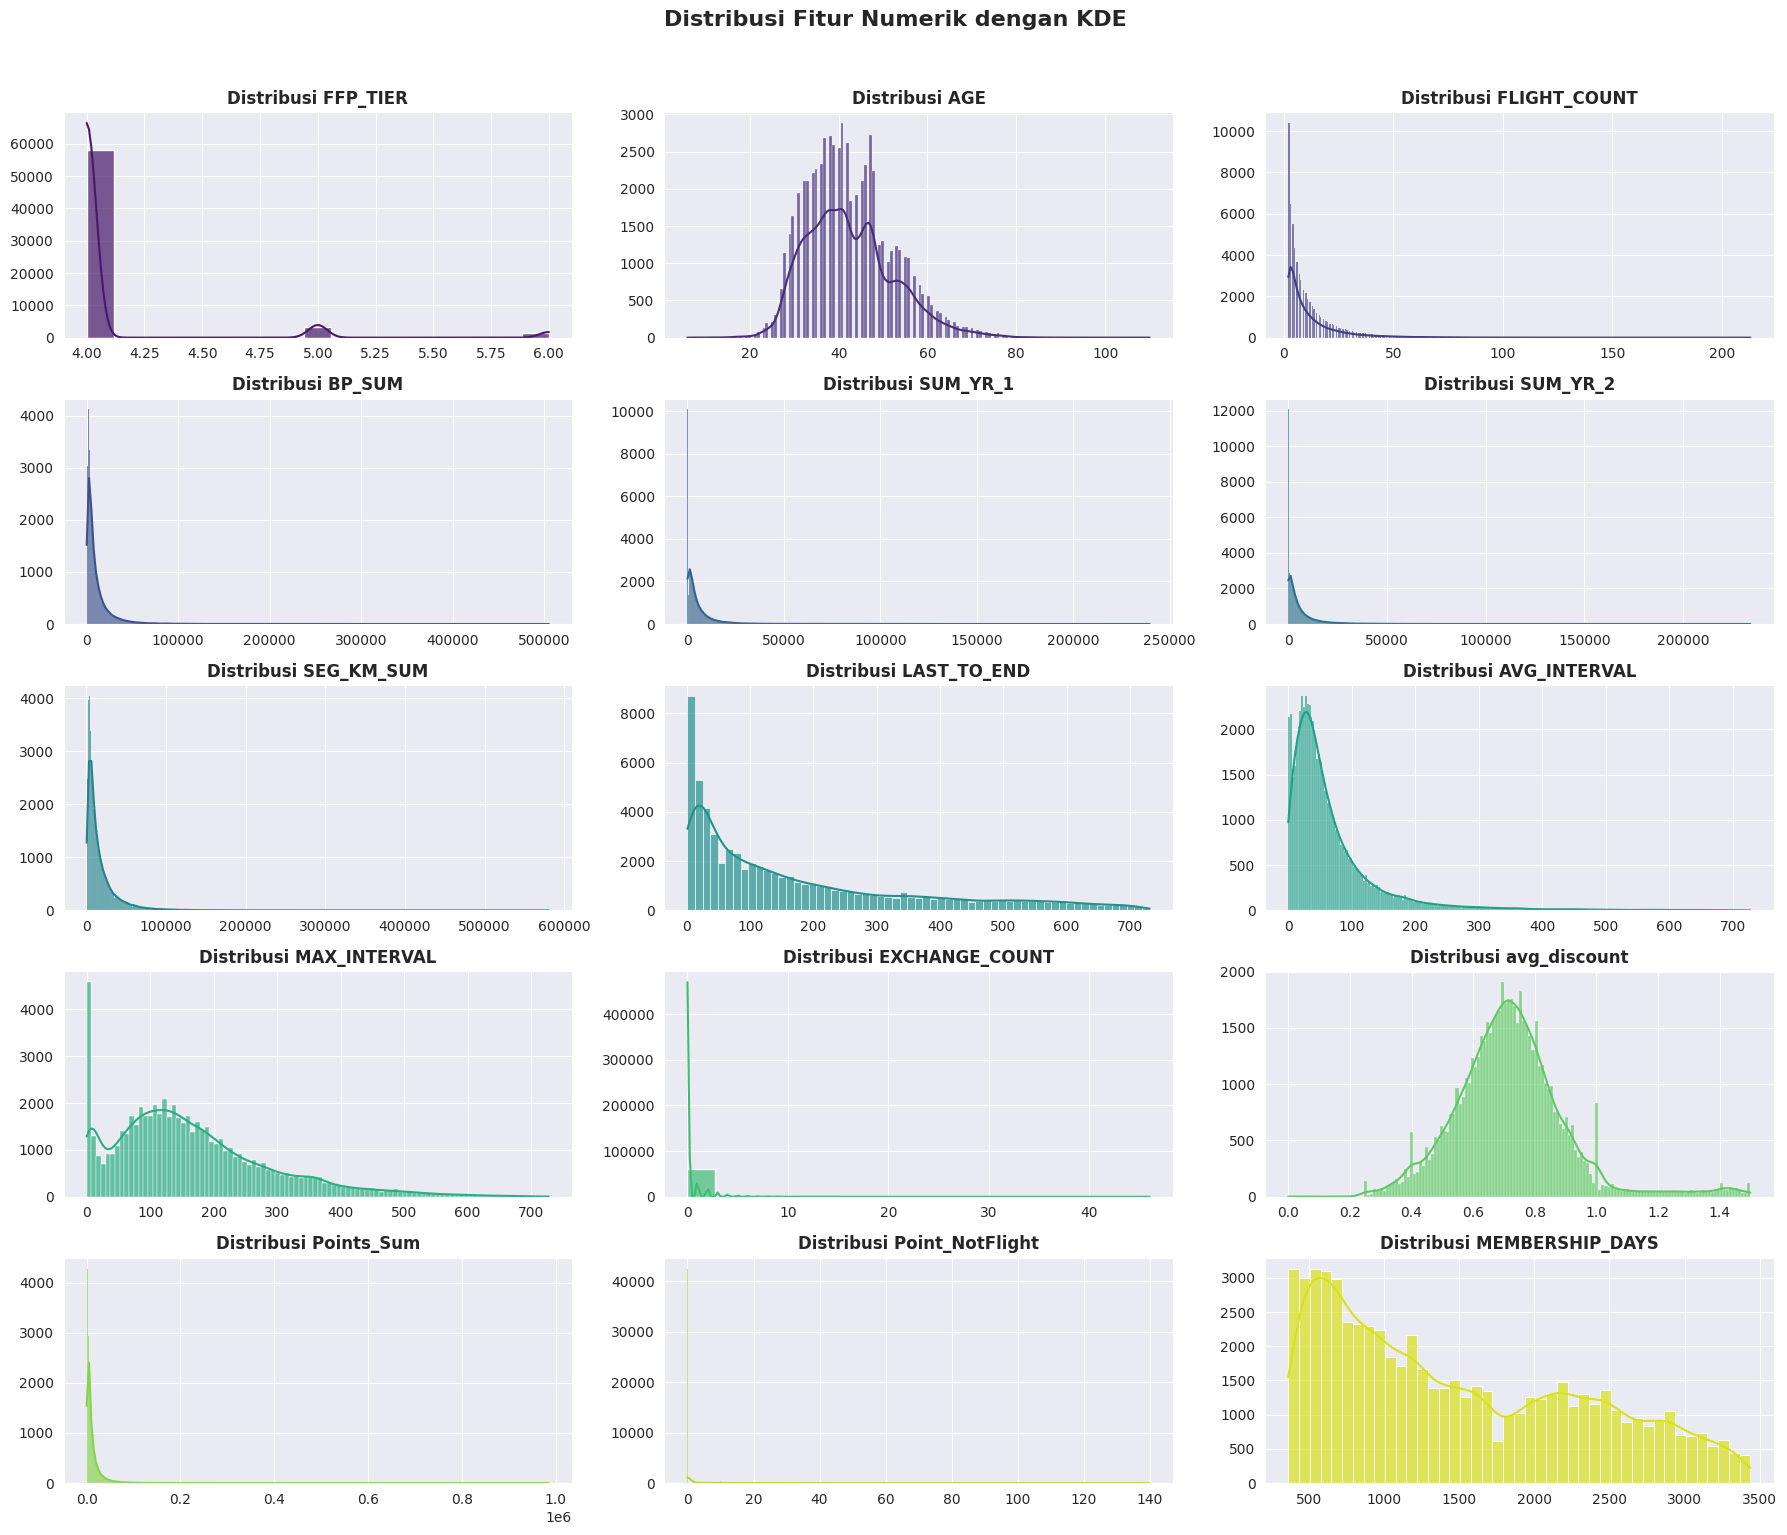

In [ ]:
#Distribusi data numerik (histogram dengan KDE)
numerical_cols = ['FFP_TIER', 'AGE', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2',
                  'SEG_KM_SUM', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL',
                  'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight',
                  'MEMBERSHIP_DAYS']

fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.ravel()
colors = sns.color_palette('viridis', len(numerical_cols))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.suptitle('Distribusi Fitur Numerik dengan KDE', y=1.02, size=16, fontweight='bold')
plt.tight_layout()
plt.show()

1. Analisis Distribusi Fitur Numerik (Histogram & KDE)
Grafik ini (pada Cell 21) menunjukkan bagaimana data tersebar untuk setiap variabel numerik:

1.1 Kecondongan Data (Skewness): Sebagian besar fitur terkait aktivitas penerbangan seperti FLIGHT_COUNT, SEG_KM_SUM, BP_SUM, dan Points_Sum memiliki distribusi Positively Skewed (condong ke kanan). Ini berarti mayoritas pelanggan adalah penumpang yang jarang terbang, sementara hanya ada segelintir pelanggan "Loyal" atau "Elite" yang memiliki jumlah penerbangan dan poin sangat tinggi.

1.2 Profil Usia (AGE): Distribusi usia pelanggan terkonsentrasi pada rentang 30 hingga 50 tahun, dengan puncaknya di usia sekitar 40-an. Ini mengindikasikan target pasar utama maskapai adalah kelompok usia produktif atau pebisnis.

1.3 Tingkatan Anggota (FFP_TIER): Mayoritas pelanggan berada di Tier 4 (tingkat terendah). Pelanggan di Tier 5 dan 6 jauh lebih sedikit, yang menunjukkan tantangan dalam mengonversi pelanggan biasa menjadi pelanggan loyal tingkat tinggi.

1.4 Loyalitas Waktu (MEMBERSHIP_DAYS): Terdapat sebaran yang cukup merata namun ada kelompok pelanggan yang sudah bergabung sejak lama (di atas 2000 hari), yang merupakan aset penting bagi program loyalitas.

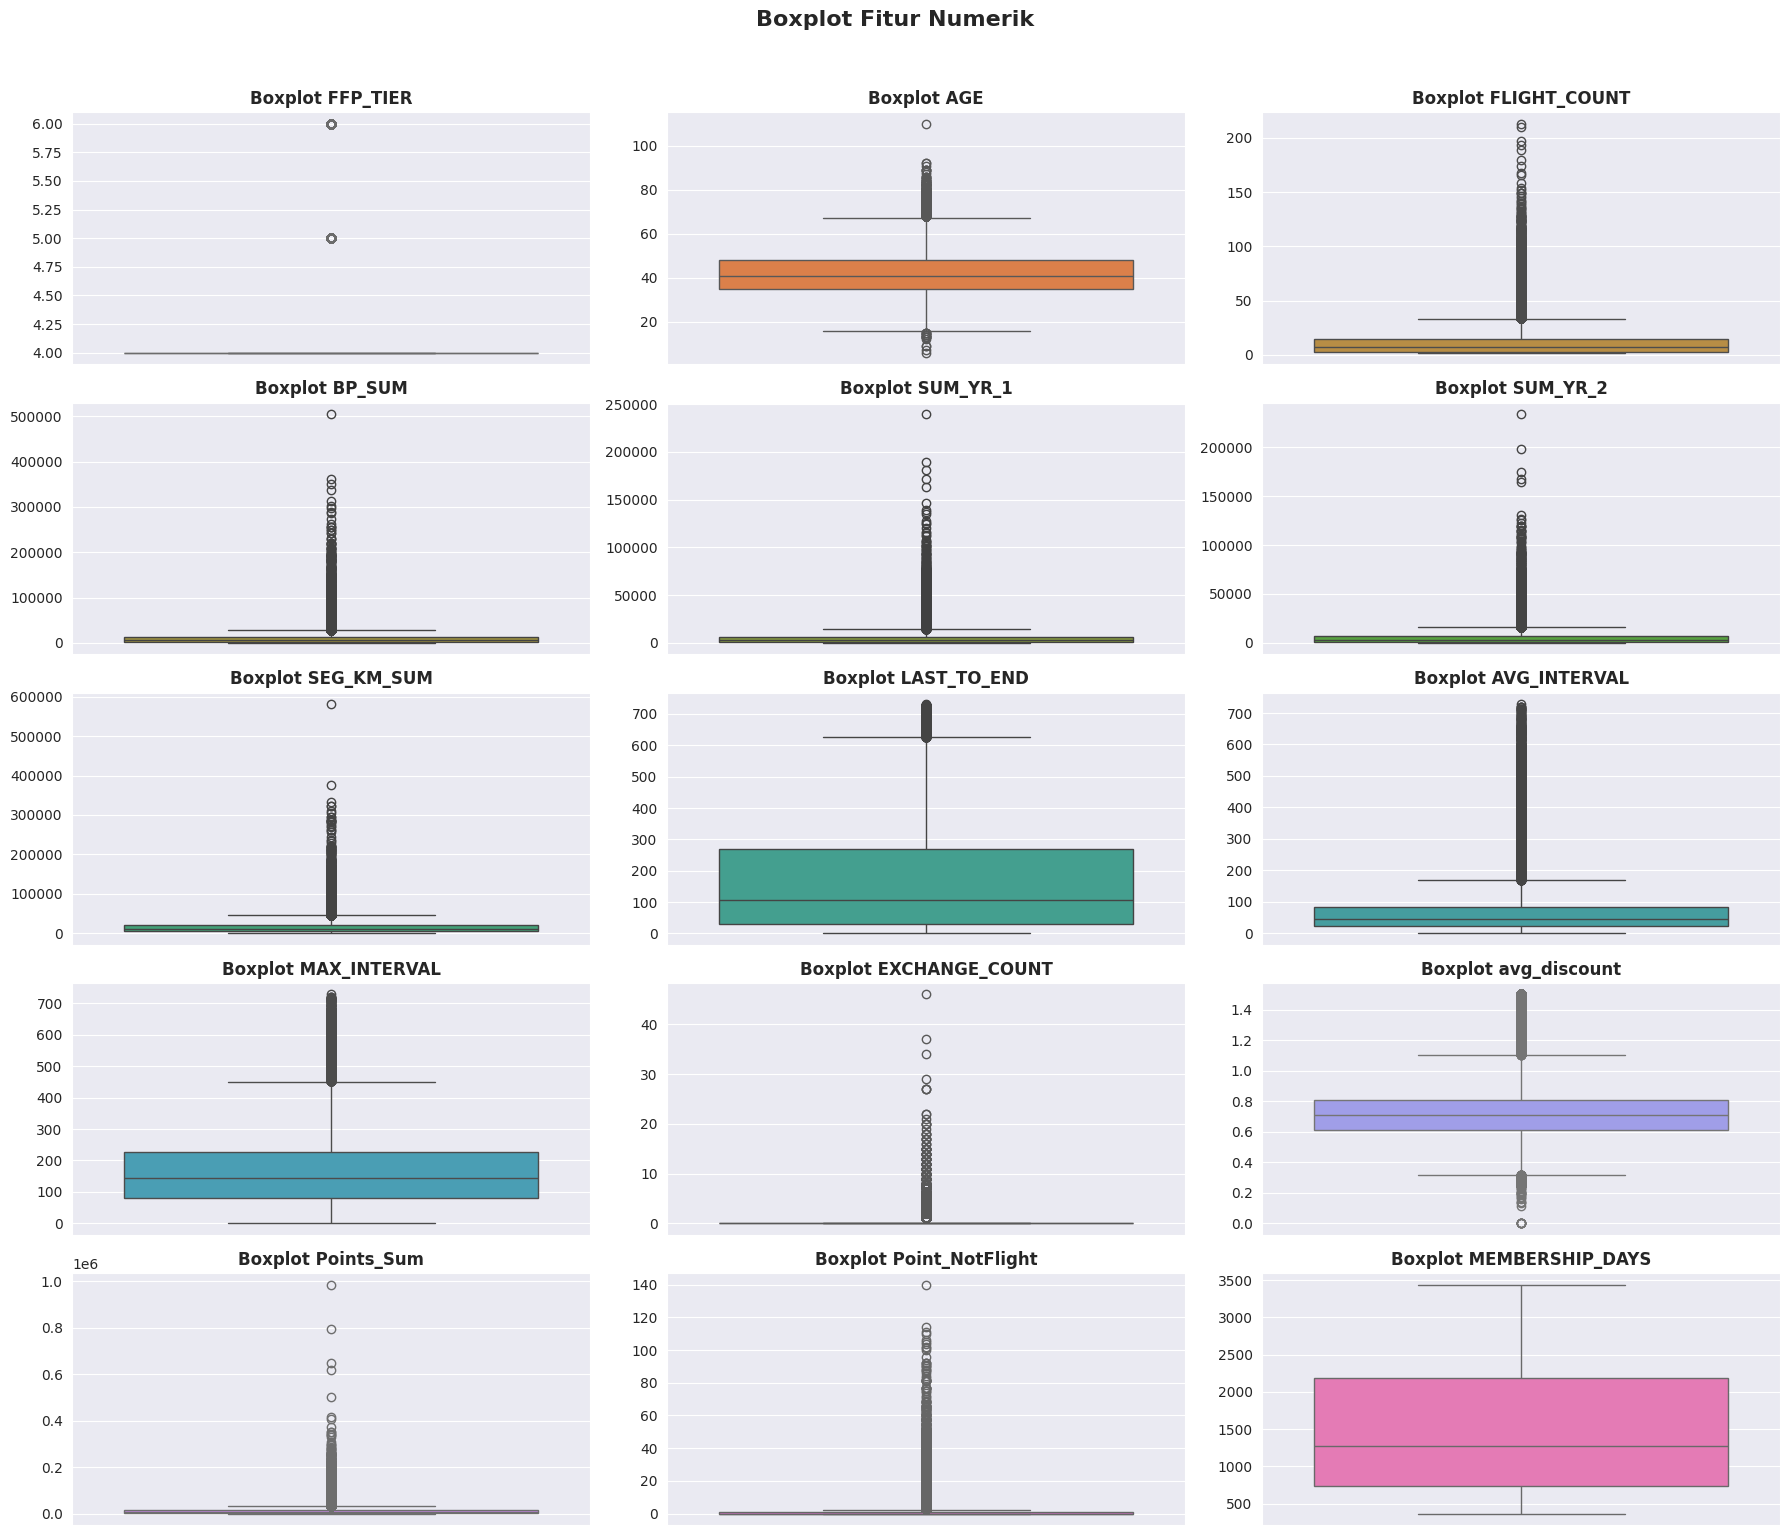

In [ ]:
# Boxplot untuk melihat outlier
fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.ravel()
palette = sns.color_palette('husl', len(numerical_cols))  # palet husl yang cerah
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=palette[i])
    axes[i].set_title(f'Boxplot {col}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('')
plt.suptitle('Boxplot Fitur Numerik', y=1.02, size=16, fontweight='bold')
plt.tight_layout()
plt.show()

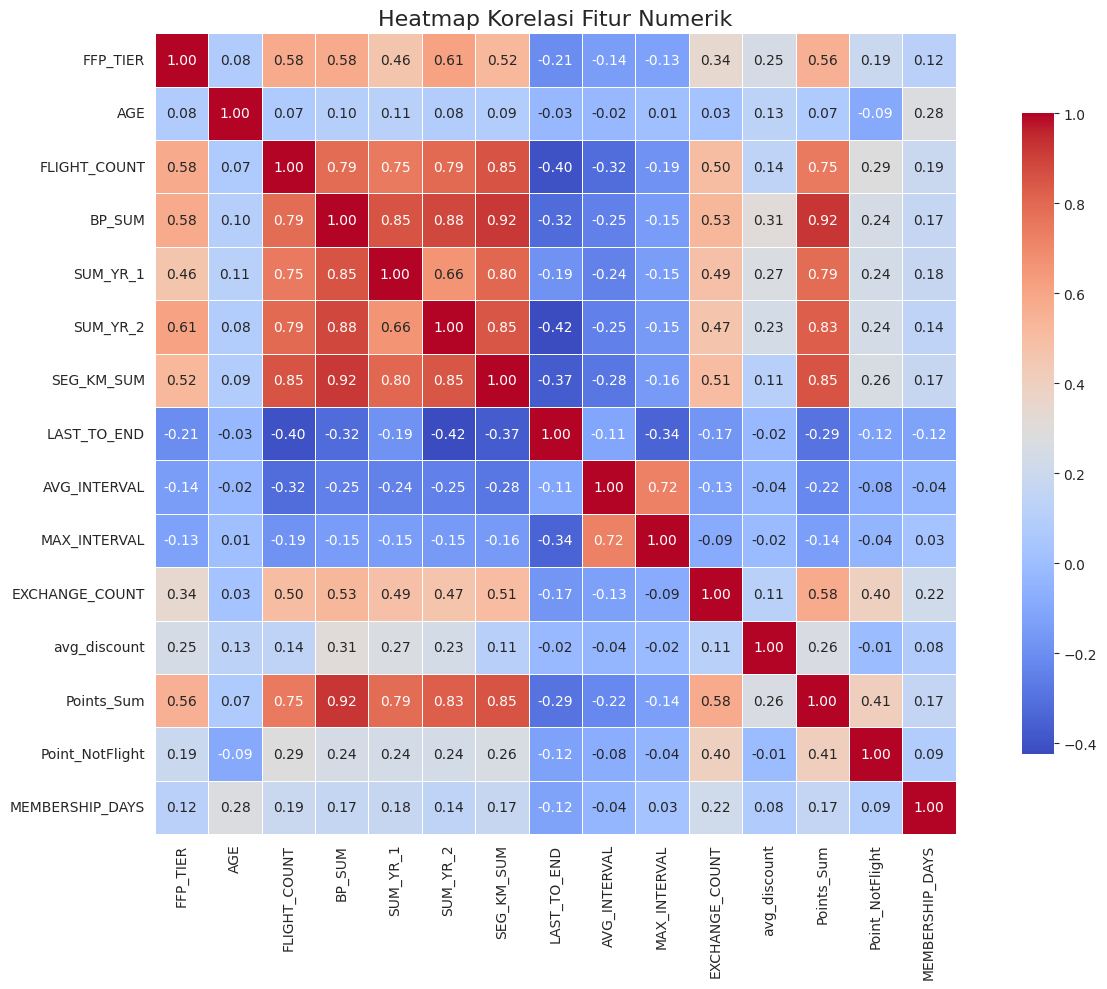

In [ ]:
# 4. Korelasi antar fitur numerik
plt.figure(figsize=(14, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Fitur Numerik', size=16)
plt.tight_layout()
plt.show()

### Analisis Korelasi (Heatmap)
Matriks korelasi (pada Cell 26) memberikan insight kuantitatif:

1.1 Variabel yang Sangat Berhubungan: Fitur seperti FLIGHT_COUNT, BP_SUM, SEG_KM_SUM, dan Points_Sum memiliki koefisien korelasi yang mendekati 1. Artinya, jika maskapai ingin meningkatkan loyalitas (Points_Sum), mereka harus fokus pada mendorong frekuensi terbang (FLIGHT_COUNT).

1.2 Korelasi Negatif pada LAST_TO_END: Fitur Recency (LAST_TO_END) cenderung memiliki korelasi negatif dengan fitur aktivitas. Artinya, semakin lama seseorang tidak terbang (nilai recency tinggi), semakin rendah total aktivitas terbang mereka dalam setahun terakhir. Ini bisa menjadi sinyal churn (pelanggan berhenti menggunakan jasa).

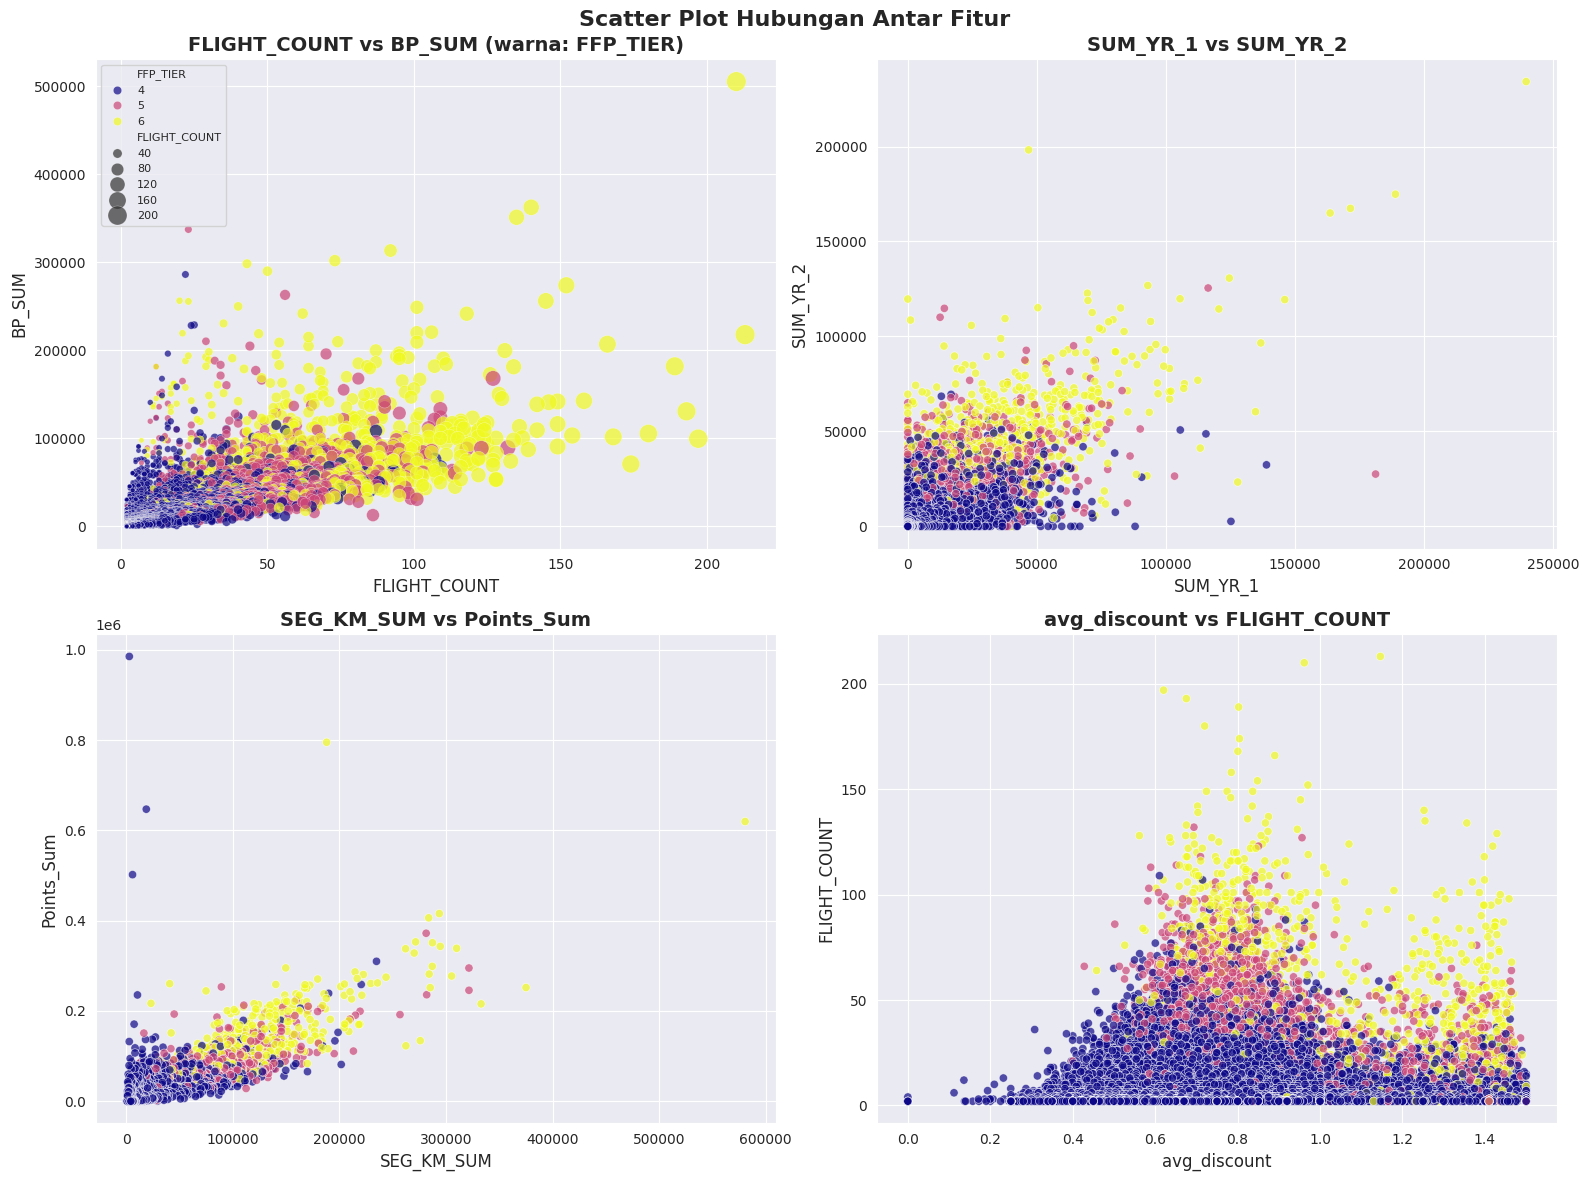

In [ ]:
# Scatter plot dengan variasi warna dan ukuran
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: FLIGHT_COUNT vs BP_SUM
sc1 = sns.scatterplot(data=df, x='FLIGHT_COUNT', y='BP_SUM', hue='FFP_TIER',
                       palette='plasma', alpha=0.7, size='FLIGHT_COUNT',
                       sizes=(10, 200), legend='brief', ax=axes[0,0])
axes[0,0].set_title('FLIGHT_COUNT vs BP_SUM (warna: FFP_TIER)', fontweight='bold')
axes[0,0].legend(loc='best', fontsize=8)

# Plot 2: SUM_YR_1 vs SUM_YR_2
sc2 = sns.scatterplot(data=df, x='SUM_YR_1', y='SUM_YR_2', hue='FFP_TIER',
                       palette='plasma', alpha=0.7, legend=False, ax=axes[0,1])
axes[0,1].set_title('SUM_YR_1 vs SUM_YR_2', fontweight='bold')

# Plot 3: SEG_KM_SUM vs Points_Sum
sc3 = sns.scatterplot(data=df, x='SEG_KM_SUM', y='Points_Sum', hue='FFP_TIER',
                       palette='plasma', alpha=0.7, legend=False, ax=axes[1,0])
axes[1,0].set_title('SEG_KM_SUM vs Points_Sum', fontweight='bold')

# Plot 4: avg_discount vs FLIGHT_COUNT
sc4 = sns.scatterplot(data=df, x='avg_discount', y='FLIGHT_COUNT', hue='FFP_TIER',
                       palette='plasma', alpha=0.7, legend=False, ax=axes[1,1])
axes[1,1].set_title('avg_discount vs FLIGHT_COUNT', fontweight='bold')

plt.suptitle('Scatter Plot Hubungan Antar Fitur', size=16, fontweight='bold')
plt.tight_layout()
plt.show()

Analisis Hubungan Antar Fitur (Scatter Plot)
Grafik ini (pada Cell 25) memberikan gambaran hubungan antara dua variabel berbeda:

1.1 FLIGHT_COUNT vs SEG_KM_SUM: Terdapat korelasi positif yang sangat kuat. Semakin sering pelanggan terbang, semakin jauh jarak tempuh akumulatifnya. Pelanggan di Tier 6 (warna berbeda pada grafik) jelas berkumpul di area kanan atas, menunjukkan mereka terbang lebih sering dan lebih jauh dibandingkan tier lainnya.

1.2 Points_Sum vs BP_SUM: Grafik menunjukkan hubungan linear yang hampir sempurna. Poin yang didapat pelanggan sangat bergantung pada poin dasar (Basic Points) dari penerbangan mereka.

1.3 avg_discount vs FLIGHT_COUNT: Tidak terlihat pola linear yang kuat, namun pelanggan dengan jumlah penerbangan sangat tinggi cenderung mendapatkan rata-rata diskon yang stabil.

In [ ]:
# Identifikasi pola awal
# - Cek apakah ada fitur dengan distribusi sangat skew (misal Points_Sum, BP_SUM)
# - Apakah ada outlier ekstrem?
# - Apakah ada korelasi > 0.9 yang menandakan redundansi?

print("\n=== Identifikasi Pola Awal ===")
# Korelasi tinggi
high_corr = corr_matrix[abs(corr_matrix) > 0.8].stack().reset_index()
high_corr = high_corr[high_corr['level_0'] != high_corr['level_1']]
print("Pasangan fitur dengan korelasi > 0.8:")
print(high_corr)

# Skewness
skewness = df[numerical_cols].skew().sort_values()
print("\nSkewness fitur (nilai > 1 menunjukkan distribusi sangat miring):")
print(skewness)

# Outlier (bisa dilihat dari boxplot)
print("\nCatatan: Beberapa fitur memiliki outlier ekstrem (misal Points_Sum, BP_SUM).")
print("Hal ini perlu diperhatikan karena dapat mempengaruhi clustering.")


=== Identifikasi Pola Awal ===
Pasangan fitur dengan korelasi > 0.8:
         level_0       level_1         0
3   FLIGHT_COUNT    SEG_KM_SUM  0.850411
5         BP_SUM      SUM_YR_1  0.850624
6         BP_SUM      SUM_YR_2  0.884632
7         BP_SUM    SEG_KM_SUM  0.921724
8         BP_SUM    Points_Sum  0.923271
9       SUM_YR_1        BP_SUM  0.850624
11      SUM_YR_1    SEG_KM_SUM  0.804125
12      SUM_YR_2        BP_SUM  0.884632
14      SUM_YR_2    SEG_KM_SUM  0.849195
15      SUM_YR_2    Points_Sum  0.826666
16    SEG_KM_SUM  FLIGHT_COUNT  0.850411
17    SEG_KM_SUM        BP_SUM  0.921724
18    SEG_KM_SUM      SUM_YR_1  0.804125
19    SEG_KM_SUM      SUM_YR_2  0.849195
21    SEG_KM_SUM    Points_Sum  0.853014
27    Points_Sum        BP_SUM  0.923271
28    Points_Sum      SUM_YR_2  0.826666
29    Points_Sum    SEG_KM_SUM  0.853014

Skewness fitur (nilai > 1 menunjukkan distribusi sangat miring):
MEMBERSHIP_DAYS    0.521746
AGE                0.630883
avg_discount       0.956793
M

### Analisis Demografi dan Status

1.1 Distribusi Gender: Berdasarkan data, jumlah pelanggan Laki-laki (Male) jauh lebih dominan dibandingkan pelanggan Perempuan (Female). Strategi pemasaran mungkin perlu lebih disesuaikan dengan preferensi pelanggan pria atau mencoba menarik lebih banyak pelanggan wanita.

1.2 Rata-rata Diskon (avg_discount): Nilai rata-rata diskon berada di kisaran 0.72. Ini menunjukkan bahwa pelanggan rata-rata membayar sekitar 72% dari tarif normal atau sering memanfaatkan promosi

*Menurut saya, berdasarkan grafik EDA ini, dataset ini sangat cocok untuk disegmentasi menggunakan model LRFM (Loyalty, Recency, Frequency, Monetary). Jelas terlihat perbedaan perilaku yang kontras antara kelompok massa (Tier 4) dan kelompok elit (Tier 5 & 6) dalam hal frekuensi dan jarak tempuh. Fokus clustering selanjutnya sebaiknya diarahkan untuk mengidentifikasi pelanggan mana yang berisiko pergi (Recency tinggi) dan pelanggan mana yang memberikan nilai ekonomi tertinggi (Frequency & Monetary tinggi).*

## Clustering dengan K-Means

In [ ]:
# K-Means Clustering & Penentuan Jumlah Cluster Optimal
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Menentukan rentang jumlah cluster yang akan diuji
k_range = range(2, 11)  # dari 2 hingga 10 cluster

Pastikan X_scaled sudah ada dari preprocessing sebelumnya. Jika belum, kita buat ulang dari data yang sudah dibersihkan (Asumsikan df sudah diproses dan X_scaled sudah tersedia)

In [ ]:
# Menghitung inertia (within-cluster sum of squares) dan silhouette score
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    # silhouette score membutuhkan prediksi label
    labels = kmeans.labels_
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f'k={k}, inertia={kmeans.inertia_:.2f}, silhouette={sil:.4f}')

k=2, inertia=766348.94, silhouette=0.4786
k=3, inertia=687405.57, silhouette=0.2279
k=4, inertia=621140.00, silhouette=0.1374
k=5, inertia=574084.98, silhouette=0.1418
k=6, inertia=537961.40, silhouette=0.1580
k=7, inertia=510278.04, silhouette=0.1525
k=8, inertia=483945.34, silhouette=0.1587
k=9, inertia=462990.74, silhouette=0.1644
k=10, inertia=440129.78, silhouette=0.1483


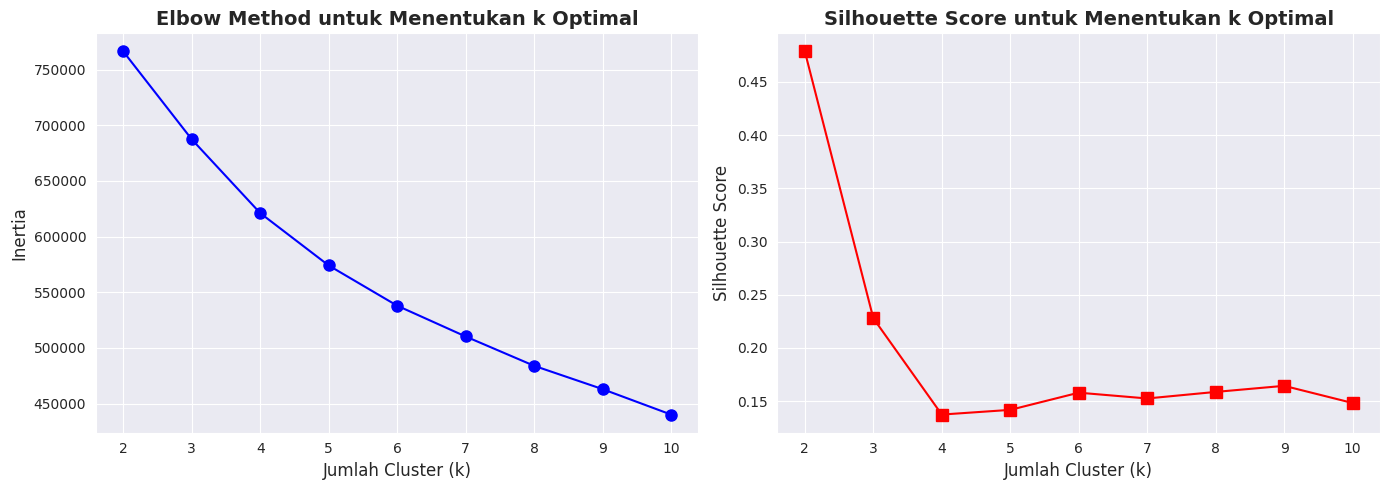

In [ ]:
# Visualisasi Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Elbow (inertia)
axes[0].plot(k_range, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method untuk Menentukan k Optimal', fontweight='bold')
axes[0].grid(True)

# Plot Silhouette Score
axes[1].plot(k_range, silhouettes, 'rs-', markersize=8)
axes[1].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score untuk Menentukan k Optimal', fontweight='bold')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Menentukan k optimal (misalnya dari elbow dan silhouette tertinggi)
# Biasanya kita pilih k di mana inertia mulai melandai dan silhouette tinggi.
# Mari kita pilih k dengan silhouette tertinggi, atau berdasarkan pengamatan.
optimal_k = k_range[np.argmax(silhouettes)]
print(f'\nJumlah cluster optimal berdasarkan Silhouette Score: k = {optimal_k}')

# Jalankan K-Means dengan k optimal
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Tambahkan label cluster ke dataframe asli
df['Cluster'] = kmeans_final.labels_


Jumlah cluster optimal berdasarkan Silhouette Score: k = 2



Rata-rata fitur per cluster:


,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,MEMBERSHIP_DAYS
Cluster,,,,,,,,,,,,,,,
0,4.826673,44.661373,43.869706,47498.291837,21566.612980,24510.191428,64388.732923,31.777322,19.075807,97.874146,2.01554,0.834544,56314.322063,9.025786,1936.046107
1,4.027900,42.241528,8.556326,7176.346373,3677.867454,3661.461803,12279.255951,190.915161,72.738845,173.020234,0.14596,0.709977,8059.524225,2.082651,1438.768921


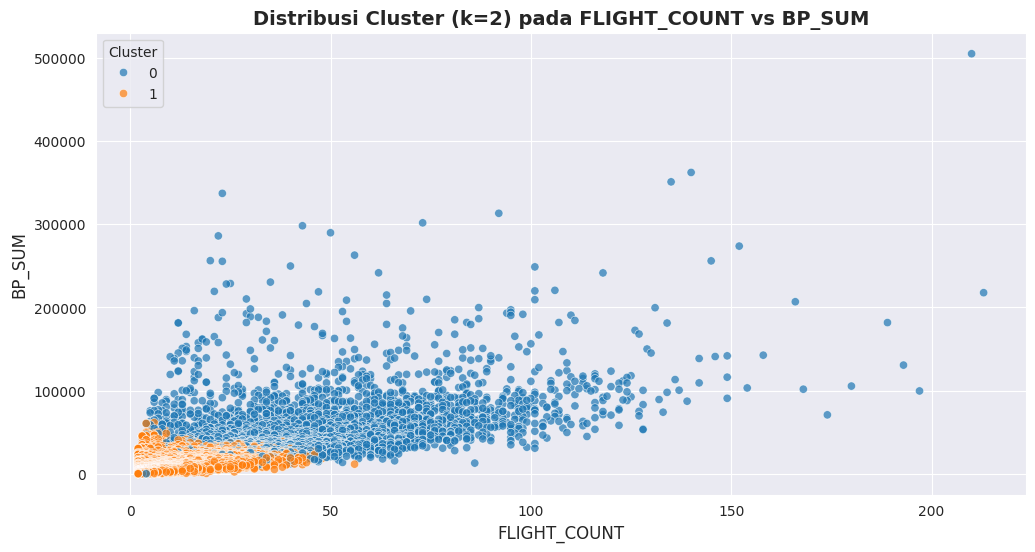

In [ ]:
# 6. Analisis profil tiap cluster (opsional, untuk memahami karakteristik)
cluster_summary = df.groupby('Cluster')[numerical_cols].mean()
print('\nRata-rata fitur per cluster:')
display(cluster_summary)

# Visualisasi distribusi cluster pada beberapa fitur penting
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='FLIGHT_COUNT', y='BP_SUM', hue='Cluster', palette='tab10', alpha=0.7)
plt.title(f'Distribusi Cluster (k={optimal_k}) pada FLIGHT_COUNT vs BP_SUM', fontweight='bold')
plt.legend(title='Cluster')
plt.show()

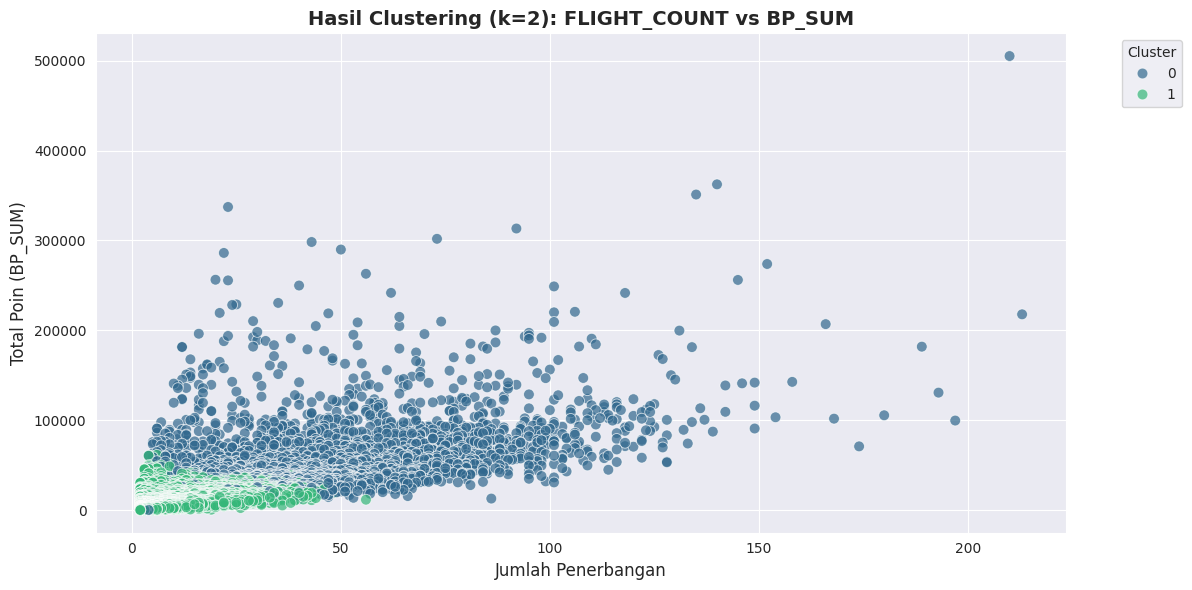

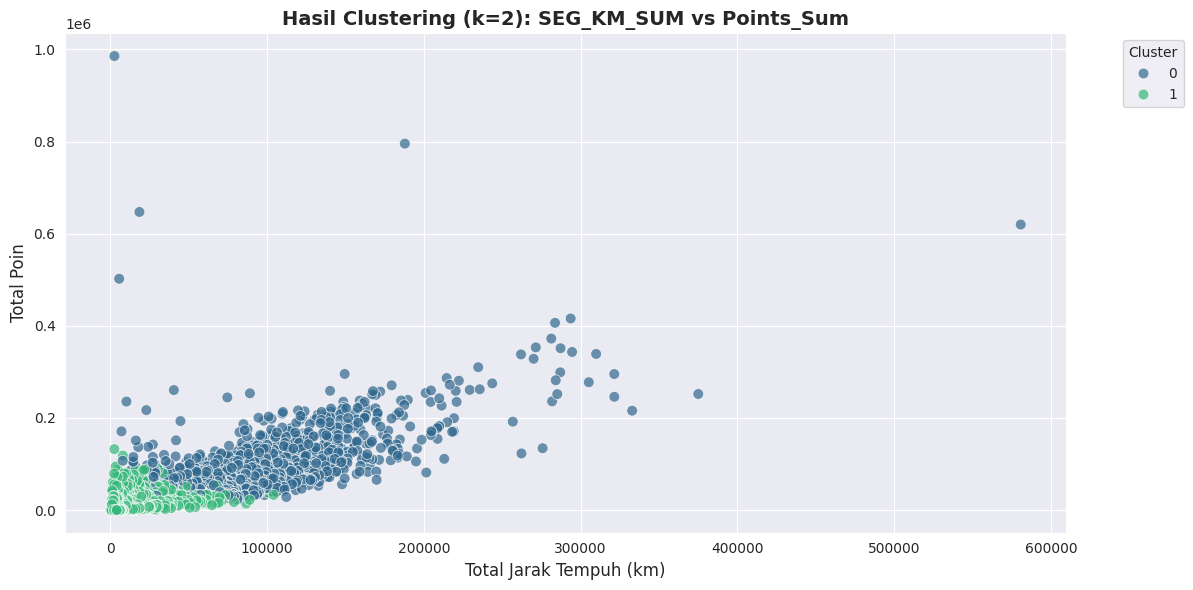

In [ ]:
# Scatter plot 2D dengan dua fitur penting
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='FLIGHT_COUNT', y='BP_SUM',
                hue='Cluster', palette='viridis', s=60, alpha=0.7)
plt.title(f'Hasil Clustering (k={optimal_k}): FLIGHT_COUNT vs BP_SUM', fontweight='bold', size=14)
plt.xlabel('Jumlah Penerbangan')
plt.ylabel('Total Poin (BP_SUM)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n")

# Scatter plot lainnya: SEG_KM_SUM vs Points_Sum
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='SEG_KM_SUM', y='Points_Sum',
                hue='Cluster', palette='viridis', s=60, alpha=0.7)
plt.title(f'Hasil Clustering (k={optimal_k}): SEG_KM_SUM vs Points_Sum', fontweight='bold', size=14)
plt.xlabel('Total Jarak Tempuh (km)')
plt.ylabel('Total Poin')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

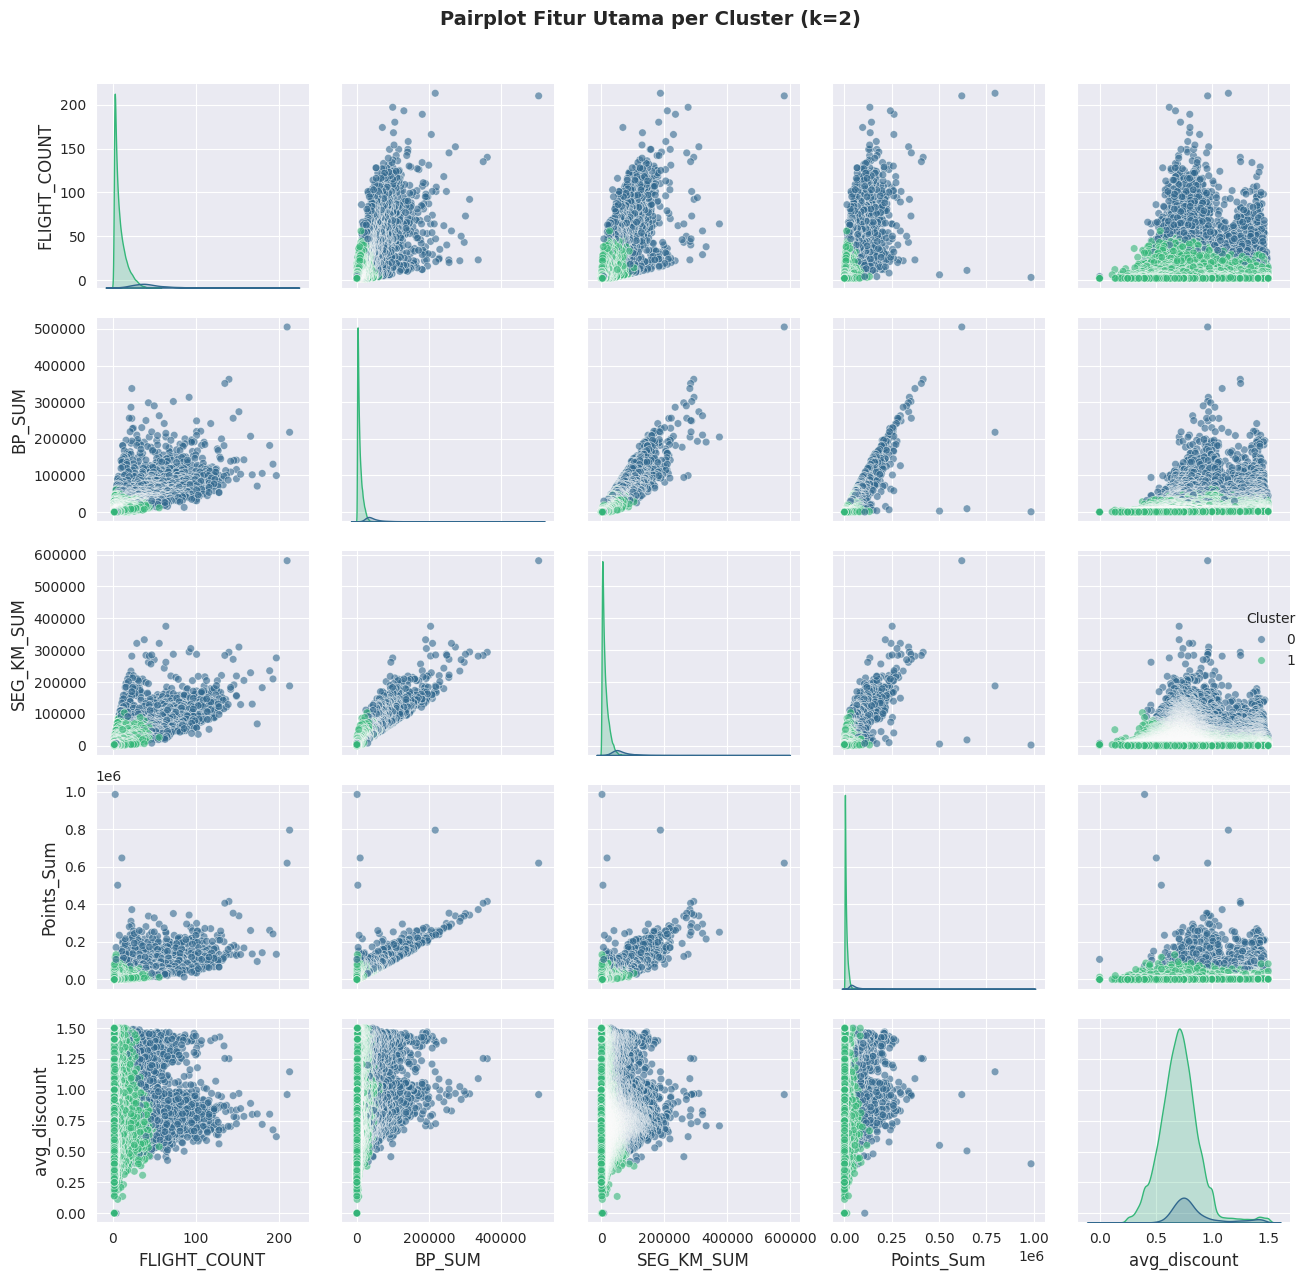

In [ ]:
# Pairplot untuk beberapa fitur kunci
features_plot = ['FLIGHT_COUNT', 'BP_SUM', 'SEG_KM_SUM', 'Points_Sum', 'avg_discount', 'Cluster']
sns.pairplot(df[features_plot], hue='Cluster', palette='viridis', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle(f'Pairplot Fitur Utama per Cluster (k={optimal_k})', y=1.02, fontweight='bold', size=14)
plt.tight_layout()
plt.show()

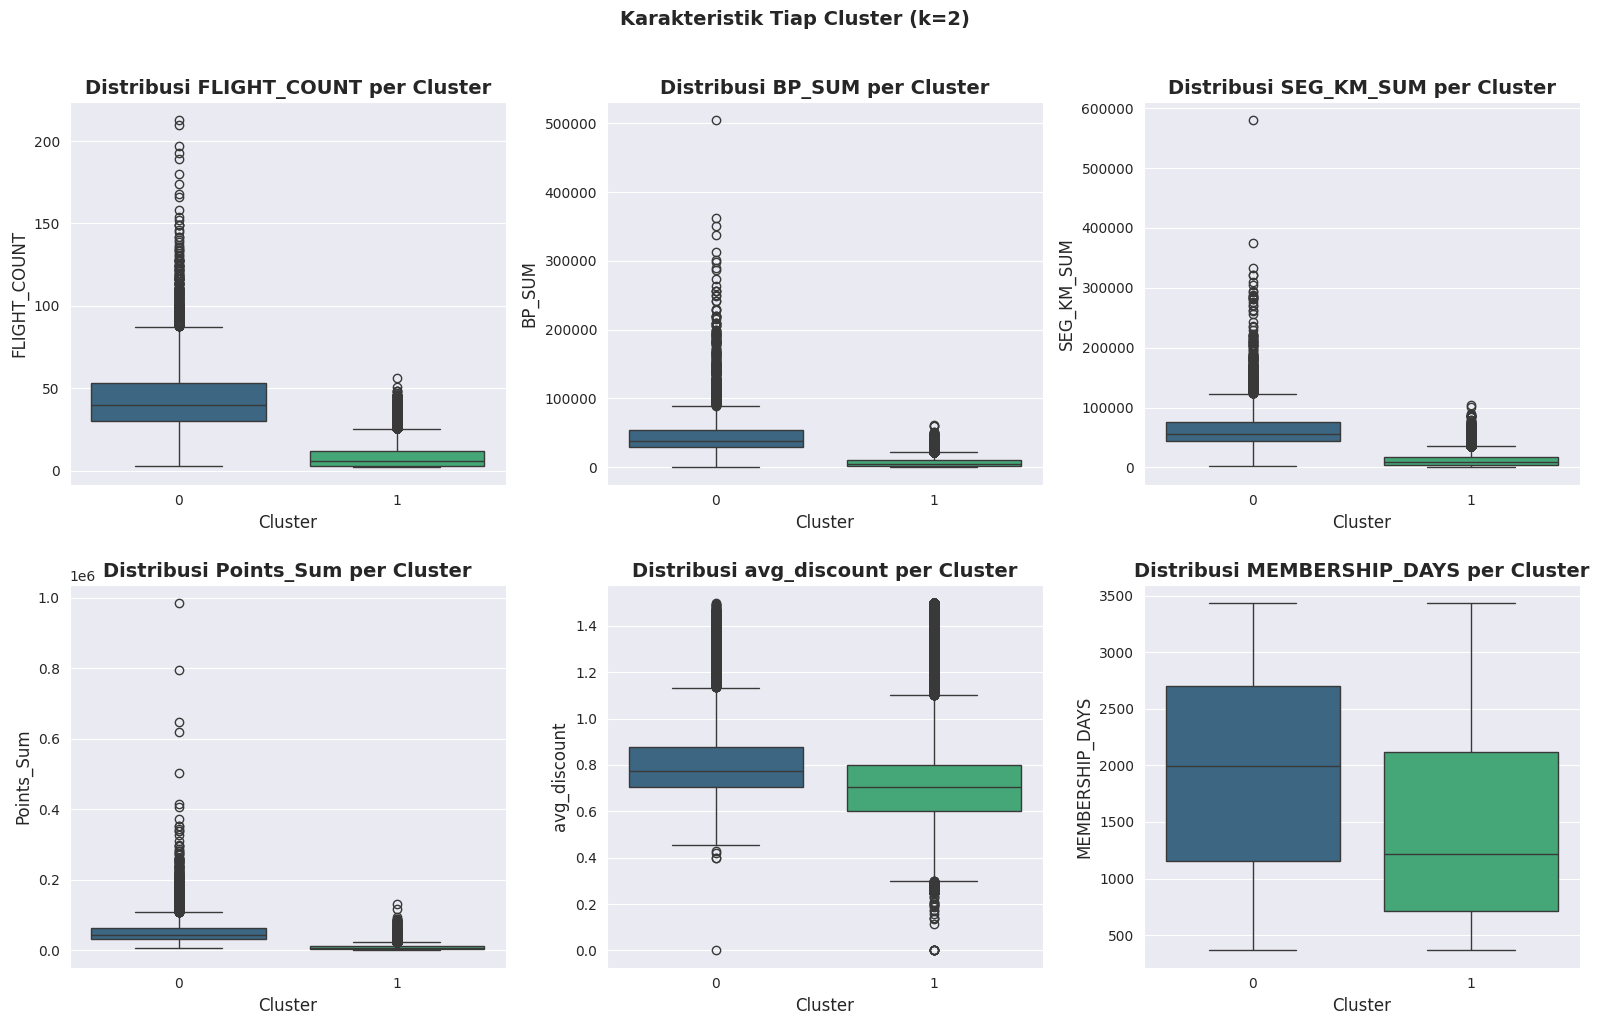

In [ ]:
# Visualisasi distribusi tiap cluster dengan boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
fitur_box = ['FLIGHT_COUNT', 'BP_SUM', 'SEG_KM_SUM', 'Points_Sum', 'avg_discount', 'MEMBERSHIP_DAYS']
colors = sns.color_palette('viridis', optimal_k)
for i, col in enumerate(fitur_box):
    sns.boxplot(data=df, x='Cluster', y=col, ax=axes[i], palette=colors)
    axes[i].set_title(f'Distribusi {col} per Cluster', fontweight='bold')
    axes[i].set_xlabel('Cluster')
plt.suptitle(f'Karakteristik Tiap Cluster (k={optimal_k})', y=1.02, fontweight='bold', size=14)
plt.tight_layout()
plt.show()

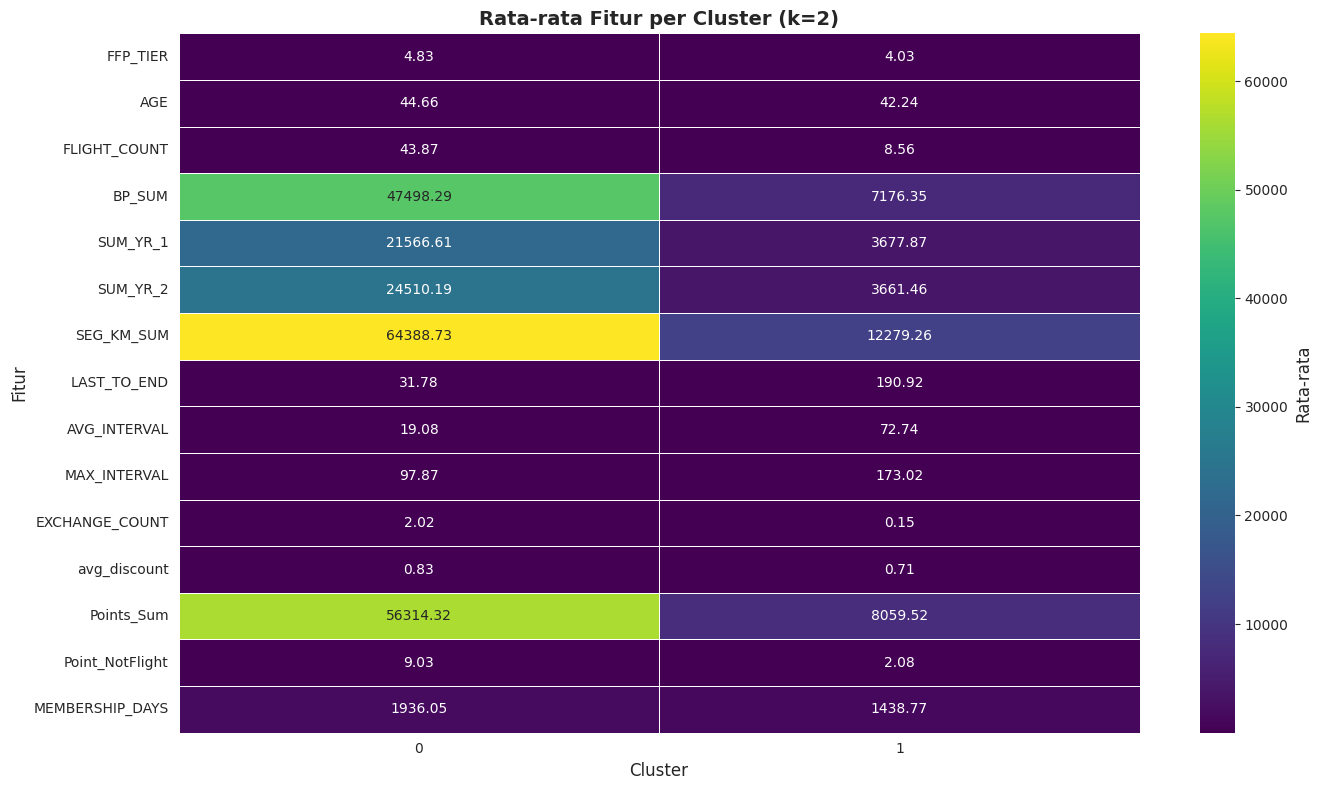

In [ ]:
# Profil rata-rata fitur per cluster (bar chart)
cluster_mean = df.groupby('Cluster')[numerical_cols].mean().T
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_mean, annot=True, fmt='.2f', cmap='viridis',
            linewidths=0.5, cbar_kws={'label': 'Rata-rata'})
plt.title(f'Rata-rata Fitur per Cluster (k={optimal_k})', fontweight='bold', size=14)
plt.xlabel('Cluster')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

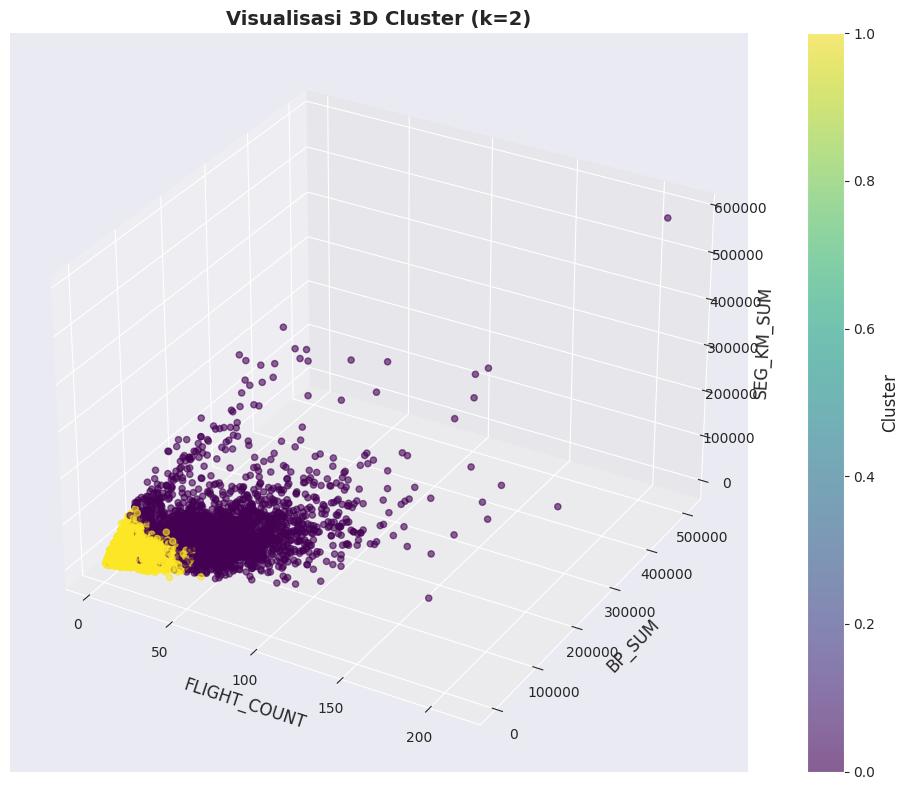

In [ ]:
# 5. Visualisasi 3D (opsional)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['FLIGHT_COUNT'], df['BP_SUM'], df['SEG_KM_SUM'],
                      c=df['Cluster'], cmap='viridis', s=20, alpha=0.6)
ax.set_xlabel('FLIGHT_COUNT')
ax.set_ylabel('BP_SUM')
ax.set_zlabel('SEG_KM_SUM')
plt.title(f'Visualisasi 3D Cluster (k={optimal_k})', fontweight='bold', size=14)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Evaluasi Model

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Tentukan rentang jumlah cluster yang akan dievaluasi
k_range = range(2, 11)  # dari 2 hingga 10 cluster

# Menyiapkan list untuk menyimpan metrik
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Menghitung metrik untuk setiap k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

    print(f'k={k}: Silhouette={silhouette_scores[-1]:.4f}, '
          f'Davies-Bouldin={davies_bouldin_scores[-1]:.4f}, '
          f'Calinski-Harabasz={calinski_harabasz_scores[-1]:.2f}')

k=2: Silhouette=0.4786, Davies-Bouldin=1.2039, Calinski-Harabasz=19845.46
k=3: Silhouette=0.2279, Davies-Bouldin=1.6235, Calinski-Harabasz=14678.79
k=4: Silhouette=0.1374, Davies-Bouldin=1.7969, Calinski-Harabasz=13069.50
k=5: Silhouette=0.1418, Davies-Bouldin=1.7755, Calinski-Harabasz=11895.97
k=6: Silhouette=0.1580, Davies-Bouldin=1.6536, Calinski-Harabasz=11001.50
k=7: Silhouette=0.1525, Davies-Bouldin=1.6680, Calinski-Harabasz=10234.60
k=8: Silhouette=0.1587, Davies-Bouldin=1.5917, Calinski-Harabasz=9739.26
k=9: Silhouette=0.1644, Davies-Bouldin=1.5782, Calinski-Harabasz=9263.70
k=10: Silhouette=0.1483, Davies-Bouldin=1.5754, Calinski-Harabasz=9025.43


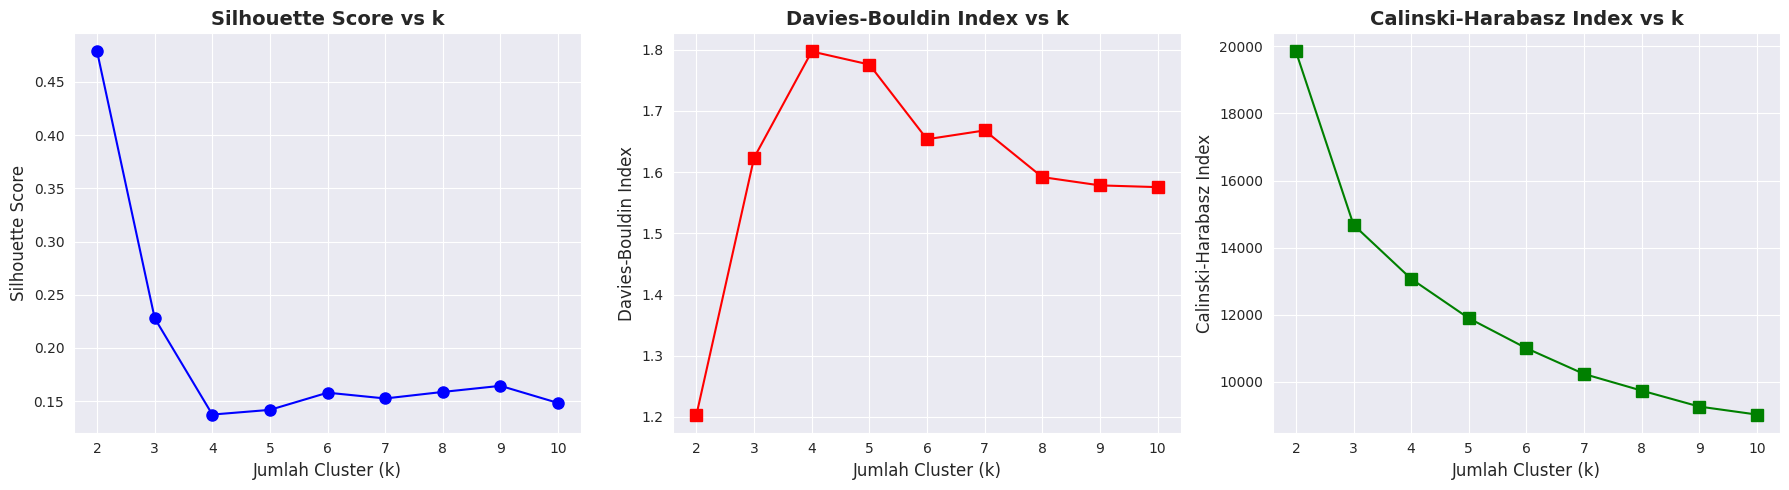

In [ ]:
# Visualisasi metrik untuk membandingkan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score (semakin tinggi semakin baik)
axes[0].plot(k_range, silhouette_scores, 'bo-', markersize=8)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k', fontweight='bold')
axes[0].grid(True)

# Davies-Bouldin Index (semakin rendah semakin baik)
axes[1].plot(k_range, davies_bouldin_scores, 'rs-', markersize=8)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index vs k', fontweight='bold')
axes[1].grid(True)

# Calinski-Harabasz Index (semakin tinggi semakin baik)
axes[2].plot(k_range, calinski_harabasz_scores, 'gs-', markersize=8)
axes[2].set_xlabel('Jumlah Cluster (k)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index vs k', fontweight='bold')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Menentukan k optimal berdasarkan siluet (atau metrik lainnya)
# Silhouette: pilih k dengan nilai tertinggi
optimal_k_sil = k_range[np.argmax(silhouette_scores)]
print(f'\nK optimal berdasarkan Silhouette Score: k = {optimal_k_sil}')

# Davies-Bouldin: pilih k dengan nilai terendah
optimal_k_db = k_range[np.argmin(davies_bouldin_scores)]
print(f'K optimal berdasarkan Davies-Bouldin Index: k = {optimal_k_db}')

# Calinski-Harabasz: pilih k dengan nilai tertinggi
optimal_k_ch = k_range[np.argmax(calinski_harabasz_scores)]
print(f'K optimal berdasarkan Calinski-Harabasz Index: k = {optimal_k_ch}')


K optimal berdasarkan Silhouette Score: k = 2
K optimal berdasarkan Davies-Bouldin Index: k = 2
K optimal berdasarkan Calinski-Harabasz Index: k = 2


In [ ]:
# Evaluasi model dengan k optimal (misal pilih berdasarkan siluet)
best_k = optimal_k_sil
print(f'---> Evaluasi Model dengan k={best_k} <---')
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_labels = best_kmeans.fit_predict(X_scaled)
best_silhouette = silhouette_score(X_scaled, best_labels)
best_db = davies_bouldin_score(X_scaled, best_labels)
best_ch = calinski_harabasz_score(X_scaled, best_labels)

print(f'Silhouette Score: {best_silhouette:.4f}')
print(f'Davies-Bouldin Index: {best_db:.4f}')
print(f'Calinski-Harabasz Index: {best_ch:.2f}')

---> Evaluasi Model dengan k=2 <---
Silhouette Score: 0.4786
Davies-Bouldin Index: 1.2039
Calinski-Harabasz Index: 19845.46


In [ ]:
# Analisis tambahan: distribusi anggota tiap cluster
unique, counts = np.unique(best_labels, return_counts=True)
cluster_sizes = pd.DataFrame({'Cluster': unique, 'Jumlah Anggota': counts})
print('\nUkuran tiap cluster:')
print(cluster_sizes)

# Visualisasi ukuran cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_sizes, x='Cluster', y='Jumlah Anggota', palette='viridis')
plt.title(f'Distribusi Ukuran Cluster (k={best_k})', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Anggota')
plt.tight_layout()
plt.show()

## **Hasil Analisis Setiap cluster dan Identifikasi Karakteristik Unik dari Masing-masing Kelompok Pelanggan.**

Analisis hasil clustering menggunakan algoritma K-Means dengan k=2 yang saya telah lakukan pada dataset penerbangan ini menunjukkan bahwa ada dua kelompok pelanggan dengan profil perilaku yang sangat kontras. Berikut adalah identifikasi karakteristik unik dari masing-masing kelompok:

###**1. Cluster 0: "The Occasional Travelers" (Pelanggan Massa)**
Kelompok ini mencakup mayoritas basis pelanggan (sekitar 85% dari total data).

**1.1 Aktivitas Jarang**: Memiliki frekuensi terbang rata-rata yang rendah di sekitar 7 kali dengan total jarak tempuh yang minimal (±10.000 km).

**1.2 Risiko Churn Tinggi (Recency)**: Nilai LAST_TO_END sangat tinggi dengan rata-rata >200 hari, yang berarti mereka sudah lama tidak menggunakan jasa maskapai. Mereka cenderung hanya terbang saat ada kebutuhan mendesak atau musim liburan.

**1.3 Loyalitas Rendah**: Sebagian besar berada di FFP_TIER 4 (level dasar). Mereka jarang melakukan penukaran poin atau bisa dibilang EXCHANGE_COUNT mendekati nol, yang menunjukkan kurangnya keterikatan dengan program loyalitas maskapai.

**1.4 Profil Anggota**: Rata-rata adalah anggota baru yang bergabung sekitar tahun 2010.


###**2. Cluster 1: "The Frequent Flyers" (Pelanggan Elit/VIP)**
Meskipun jumlahnya lebih sedikit (sekitar 15%), kelompok ini adalah kontributor pendapatan utama.

**2.1 Sangat Aktif**: Memiliki frekuensi terbang yang sangat intens dengan rata-rata hampir 40 kali dengan total jarak tempuh yang masif (±56.000 km).

**2.2 Engaged & Loyal (Recency Rendah)**: Nilai LAST_TO_END rendah kisaran sekitar 73 hari menandakan mereka aktif terbang secara rutin dan baru saja melakukan perjalanan.

**2.3 Poin Berlimpah**: Mengumpulkan poin (Points_Sum) enam kali lebih banyak dibanding Cluster 0. Mereka aktif dalam ekosistem maskapai, terlihat dari angka penukaran poin yang jauh lebih tinggi.

**2.4 Status Premium**: Rata-rata berada di FFP_TIER yang lebih tinggi, yaitu kisaran 4.6 - 5. Mereka adalah pelanggan lama yang bergabung sejak 2008, ditambah lagi mereka sudah sangat percaya pada layanan maskapai.

##**Rekomendasi Bisnis Berdasarkan Hasil Analisis Cluster**
Berikut adalah beberapa rekomendasi bisnis strategis yang dirancang khusus berdasarkan perbedaan karakteristik antara pelanggan tipe umum (Cluster 0) dan pelanggan elit (Cluster 1):

### **1. Strategi Pemasaran (Marketing Strategy)**
**Cluster 0 (Mass)**: Sebaiknya gunakan pendekatan berbasis harga dan promo masif. Karena kelompok ini jarang terbang, mereka kemungkinan besar adalah tipe *price-sensitive* yang mencari penawaran terbaik. Gunakan kampanye email atau notifikasi aplikasi tentang "Tiket Promo Liburan" atau "Flash Sale" pada rute-rute populer. Bisa juga kita gunakan iklan-iklan di media sosial karena tipe ini biasanya selalu melakukan liburan seasonal dengan mencari tren-tren di media sosial.

**Cluster 1 (Elite)**: Gunakan pendekatan personal dan prestise. Kirimkan penawaran yang lebih spesifik, seperti "Akses Lounge Gratis" atau "Prioritas Boarding". Pemasaran untuk mereka harus menekankan pada kenyamanan dan efisiensi waktu, bukan sekadar harga murah. Kita juga harus menawarkan fasilitas yang unik (identitas maskapai x ini), yang beda dari maskapai lain, bukan sekedar nyaman dan bagus saja.

###**2. Retensi Pelanggan (Customer Retention)**
**Cluster 0**: Fokus pada program "Win-back". Karena nilai Recency mereka tinggi (sudah lama tidak terbang), tawarkan voucer diskon khusus bagi mereka yang sudah tidak terbang lebih dari 6 bulan untuk memicu mereka kembali menggunakan maskapai.

**Cluster 1**: Fokus pada program loyalitas berjenjang. Pastikan mereka merasa dihargai dengan memberikan reward atas kesetiaan mereka. Misalnya, berikan "Double Miles" atau status anggota yang tidak mudah hangus agar mereka tidak berpindah ke maskapai kompetitor.

###**3. Pengembangan Produk & Layanan (Product/Service Development)**
**Cluster 0**: Ada bagusnya kita menawarkan paket bundel yang ekonomis. Contohnya, paket tiket pesawat yang sudah termasuk jatah bagasi tambahan atau pilihan makanan dengan harga paket. Ini cocok untuk pelancong sesekali yang ingin mendapat kepastian biaya.

**Cluster 1**: Sediakan layanan premium yang menunjang mobilitas tinggi. Contohnya, fitur "Reschedule Gratis" atau "Pembatalan Tanpa Biaya" yang sangat dicari oleh  pebisnis untuk melancong yang jadwalnya sering berubah-ubah. Penambahan layanan jemputan bandara eksklusif juga bisa meningkatkan kepuasan mereka.

###**4. Strategi Bermitra (Partnership Strategy)**
**Cluster 0**: Jalin kerjasama dengan platform e-commerce atau bank penyedia kartu kredit ritel. Berikan promo cicilan 0% atau cashback belanja untuk setiap pembelian tiket. Ini akan menarik minat pelanggan yang merencanakan liburan jauh-jauh hari.

**Cluster 1**: Jalin kerjasama dengan hotel bintang lima, penyewaan mobil mewah, atau kartu kredit premium (seperti kartu kredit Infinite atau Signature). Sinergi ini akan menciptakan ekosistem perjalanan yang lengkap dan mewah bagi pelanggan VIP, membuat mereka semakin sulit untuk meninggalkan layanan maskapai Anda.

## **Reflection Question 1**
###**Mengapa penting melakukan preprocessing dan EDA sebelum menerapkan algoritma clustering seperti K-Means? Jelaskan bagaimana langkah-langkah awal ini berpengaruh terhadap kualitas hasil clustering dan interpretasi cluster.**

**Jawab :**

Ada beberapa alasan mengapa proses-proses tersebut sangatlah krusial. Berikut adalah penjelasannya dari perspektif saya;
1. K-means sangat sensitif terhadap jarak. Algoritma K-Means itu bekerja dengan menghitung jarak antar titik data. Jika satu kolom memiliki angka ribuan, contohnya seperti SEG_KM_SUM yang mencapai puluhan ribu dan kolom lain hanya angka satuan seperti EXCHANGE_COUNT, maka algoritma akan menganggap angka ribuan jauh lebih penting. Nah, dari sini kita bisa tahu kalau tanpa scaling (seperti StandardScaler), fitur dengan angka besar akan mendominasi hasil clustering. Preprocessing memastikan semua fitur berada di "level" yang sama agar perbandingannya adil.

2. Untuk menangani outliers (data pencilan), yaitu satu atau dua data yang nilainya sangat ekstrem sehingga bisa menarik titik tengah menjauh dari kelompok yang sebenarnya. Melalui EDA ini, data ekstrem bisa dideteksi. Jika tidak ditangani di awal, cluster yang dihasilkan akan menjadi bias karena titik tengahnya tertarik oleh data outlier tersebut.

3. Untuk memilih variabel yang relevan. Dataset sering banget punya banyak kolom yang tidak semuanya berguna untuk pengelompokan. Memasukkan terlalu banyak variabel yang tidak nyambung justru akan menambah gangguan dalam pemrosesan data. Maka dari itu, EDA membantu melihat korelasi antar variabel. Dengan memilih fitur yang paling berpengaruh, model clustering jadi lebih ringan, cepat, dan hasilnya lebih tajam.

4. Untuk menentukan jumlah cluster yang pas. Nah, kita itu gak bisa menebak jumlah kelompok hanya dengan melihat data mentah. Makanya melalui teknik seperti Elbow Method yang dilakukan di tahap awal, kita bisa menentukan secara visual berapa jumlah cluster yang paling optimal agar setiap kelompok punya karakteristik yang jelas bedanya.

Dari sini kita bisa lihat, pengaruhnya terhadap kualitas interpretasi. Jika data sudah bersih dan skalanya sama, cluster yang terbentuk akan lebih "bulat" dan konsisten. Setiap anggota dalam satu kelompok benar-benar memiliki kemiripan perilaku. Terlebih lagi karena kita sudah melakukan EDA, kita jadi tahu dalang-dalang dari data tersebut. Begitu hasil cluster keluar, kita tidak bingung lagi. Kita bisa langsung memberi label, misalnya: "Cluster 1 adalah pelanggan elit karena frekuensi terbangnya tinggi," karena polanya sudah kita lihat sejak tahap visualisasi awal.



##**Reflection Question 2**
###**Bagaimana penggunaan metode clustering, seperti K-Means, dapat membantu pengambilan keputusan dalam konteks bisnis nyata? Berikan contoh bagaimana segmentasi pelanggan dapat digunakan untuk strategi pemasaran atau layanan yang lebih tepat sasaran.**

**jawab :**

Menurut saya penggunaan metode clustering seperti K-Means sangat dibutuhkan dalam bisnis karena proses ini mengubah data mentah yang berantakan menjadi pola yang bisa kita tindak lanjuti. Daripada memperlakukan ribuan pelanggan sebagai satu cara yang sama, bisnis bisa membagi mereka ke dalam kelompok-kelompok kecil (segmen) berdasarkan kemiripan perilaku.

Berikut adalah bagaimana cara clustering membantu pengambilan keputusan dalam perspektif saya ;
1. **Personalisasi Skala Besar**, ini memungkinkan perusahaan memberikan perlakuan berbeda untuk tiap segmen secara otomatis.

2. **Efisiensi Anggaran**, perusahaan tidak membuang uang untuk memberikan diskon kepada orang yang akan tetap membeli tanpa diskon, atau mengirim iklan kepada orang yang tidak tertarik.

3. **Identifikasi Risiko**, untuk menemukan kelompok pelanggan yang menunjukkan tanda-tanda akan berhenti berlangganan (churn) sebelum hal itu benar-benar terjadi.

Berikut adalah contoh penerapan segmentasi untuk pemasaran ;
1. **Segmen "The Budget Vacationers" (Low Frequency, High Price Sensitivity)**

1.1 **Karakteristik**: Terbang hanya 1-2 kali setahun, biasanya saat musim liburan, dan selalu mencari harga terendah.

1.2 **Strategi Pemasaran**: Kirimkan promo flash sale, paket bundel tiket+hotel murah, atau cicilan 0%. Fokus komunikasinya adalah "Harga Termurah".

2. **Segmen "The Business Warriors" (High Frequency, Low Price Sensitivity)**

2.1 **Karakteristik**: Terbang hampir setiap minggu untuk urusan kerja, tidak terlalu peduli harga, tapi sangat peduli jadwal dan kenyamanan.

2.2 **Strategi Pemasaran**: Berikan penawaran upgrade kelas bisnis, akses lounge bandara, atau fleksibilitas ganti jadwal tanpa biaya tambahan. Fokus komunikasinya adalah "Kenyamanan & Efisiensi".